In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler

In [2]:
GSE63060_path = "/content/drive/MyDrive/Colab Notebooks/Personal/brain_disease_prediction/GEO/Alzheimer/blood tissue/GSE63060_expression.csv"
GSE63061_path = "/content/drive/MyDrive/Colab Notebooks/Personal/brain_disease_prediction/GEO/Alzheimer/blood tissue/GSE63061_expression.csv"

In [3]:
GSE63060 = pd.read_csv(GSE63060_path)
GSE63061 = pd.read_csv(GSE63061_path)

In [4]:
GSE63060.rename(columns={'Unnamed: 0':'patient_id'}, inplace=True)
GSE63061.rename(columns={'Unnamed: 0':'patient_id'}, inplace=True)

In [5]:
GSE63060.set_index('patient_id', inplace=True)
GSE63061.set_index('patient_id', inplace=True)

In [6]:
GSE63061

,1-Dec,1-Mar,2-Mar,3-Mar,5-Mar,6-Mar,7-Mar,8-Mar,9-Mar,A1BG,...,ZYG11A,ZYG11B,ZYX,ZZEF1,ZZZ3,dJ222E13.2,dJ341D10.1,gm127,psiTPTE22,status
patient_id,,,,,,,,,,,,,,,,,,,,,
GSM1539409,6.046115,6.268807,7.793198,6.247908,6.217792,7.715288,7.880070,6.898175,6.097052,6.363700,...,6.024313,8.223230,9.639303,7.686363,6.312076,6.051220,6.236891,6.114106,6.017242,MCI
GSM1539410,6.068269,6.332623,7.822572,6.253956,6.146553,7.815891,7.950036,6.631771,6.110334,6.038703,...,6.044935,8.423643,10.255327,7.729719,6.234654,6.083923,6.398889,6.144168,6.022783,MCI
GSM1539411,6.049894,6.451657,7.821084,6.299298,6.231308,8.063262,8.578855,7.258313,6.028404,6.149995,...,6.050358,8.126528,9.643614,7.526946,6.441426,6.059549,6.322824,6.043692,6.096135,MCI
GSM1539412,6.022627,6.204796,8.183803,6.242987,6.073113,8.299693,7.528975,7.545952,6.125845,6.364765,...,6.024002,8.443437,9.966027,7.485560,6.167969,6.079597,6.177225,6.192038,6.032421,MCI
GSM1539413,6.024455,6.410122,8.448412,6.185270,6.168115,8.330396,8.040028,7.083462,6.071435,6.154938,...,6.014700,8.657116,9.640727,7.288133,6.422155,6.029469,6.324525,6.072912,6.056553,MCI
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
GSM1539792,6.050681,6.393572,7.546375,6.252932,6.226305,8.170299,7.806016,6.963304,6.062263,6.139319,...,6.086113,8.659101,10.350903,7.713113,6.271670,6.104885,6.656707,6.005648,6.031678,MCI
GSM1539793,6.110553,6.376821,8.007593,6.263650,6.138989,8.021647,7.953865,6.968087,5.999827,6.192208,...,6.022127,8.149314,9.762687,7.363716,6.354014,6.010161,6.407741,6.259958,6.103267,MCI
GSM1539794,6.017178,6.375036,7.813062,6.132921,6.176351,8.116965,8.569122,6.976714,6.016029,6.089414,...,6.053900,8.218770,9.624390,7.468304,6.346038,6.088197,6.388553,6.107970,6.044537,AD


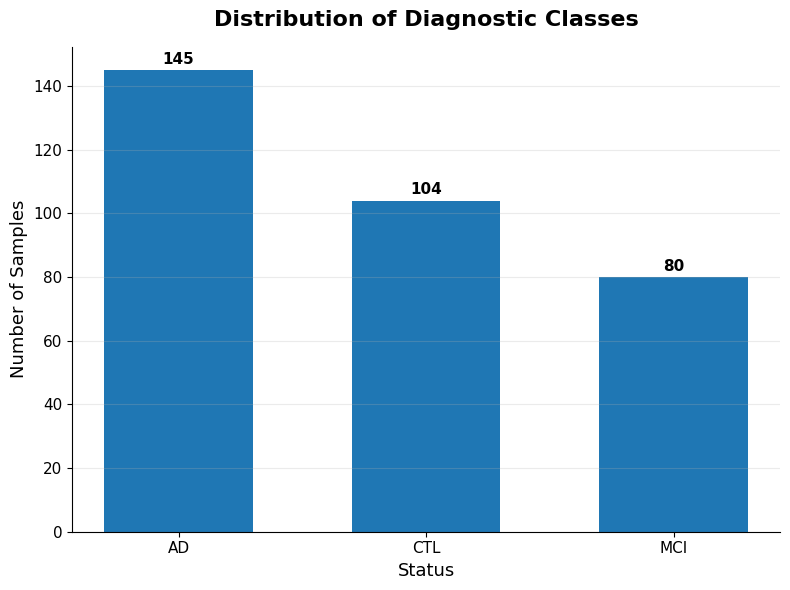

In [17]:
status_counts = GSE63060["status"].value_counts()

# Create figure
plt.figure(figsize=(8, 6))

# Bar plot
bars = plt.bar(
    status_counts.index,
    status_counts.values,
    width=0.6
)

# Add values on top
for bar in bars:
    height = bar.get_height()
    plt.text(
        bar.get_x() + bar.get_width()/2,
        height + 2,
        f"{int(height)}",
        ha='center',
        fontsize=11,
        fontweight='bold'
    )

# Labels and title
plt.title(
    "Distribution of Diagnostic Classes",
    fontsize=16,
    fontweight='bold',
    pad=15
)

plt.xlabel("Status", fontsize=13)
plt.ylabel("Number of Samples", fontsize=13)

# Grid
plt.grid(axis='y', alpha=0.25)

# Clean top/right borders
ax = plt.gca()
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

# Improve ticks
plt.xticks(fontsize=11)
plt.yticks(fontsize=11)

plt.tight_layout()
plt.show()

In [7]:
status_labels = GSE63060['status']
gene_expression_df = GSE63060.drop(columns=['status'])

In [8]:
gene_expression_df = gene_expression_df.astype(float)


status_labels = status_labels.reindex(gene_expression_df.index)


top_genes = gene_expression_df.var().sort_values(ascending=False).head(200).index
gene_expression_df = gene_expression_df[top_genes]

In [9]:
#Normilization
gene_expression_df = pd.DataFrame(
    StandardScaler().fit_transform(gene_expression_df),
    index=gene_expression_df.index,
    columns=gene_expression_df.columns
)

/usr/local/lib/python3.12/dist-packages/seaborn/matrix.py:560: UserWarning: Clustering large matrix with scipy. Installing `fastcluster` may give better performance.
  warnings.warn(msg)
/usr/local/lib/python3.12/dist-packages/seaborn/matrix.py:560: UserWarning: Clustering large matrix with scipy. Installing `fastcluster` may give better performance.
  warnings.warn(msg)


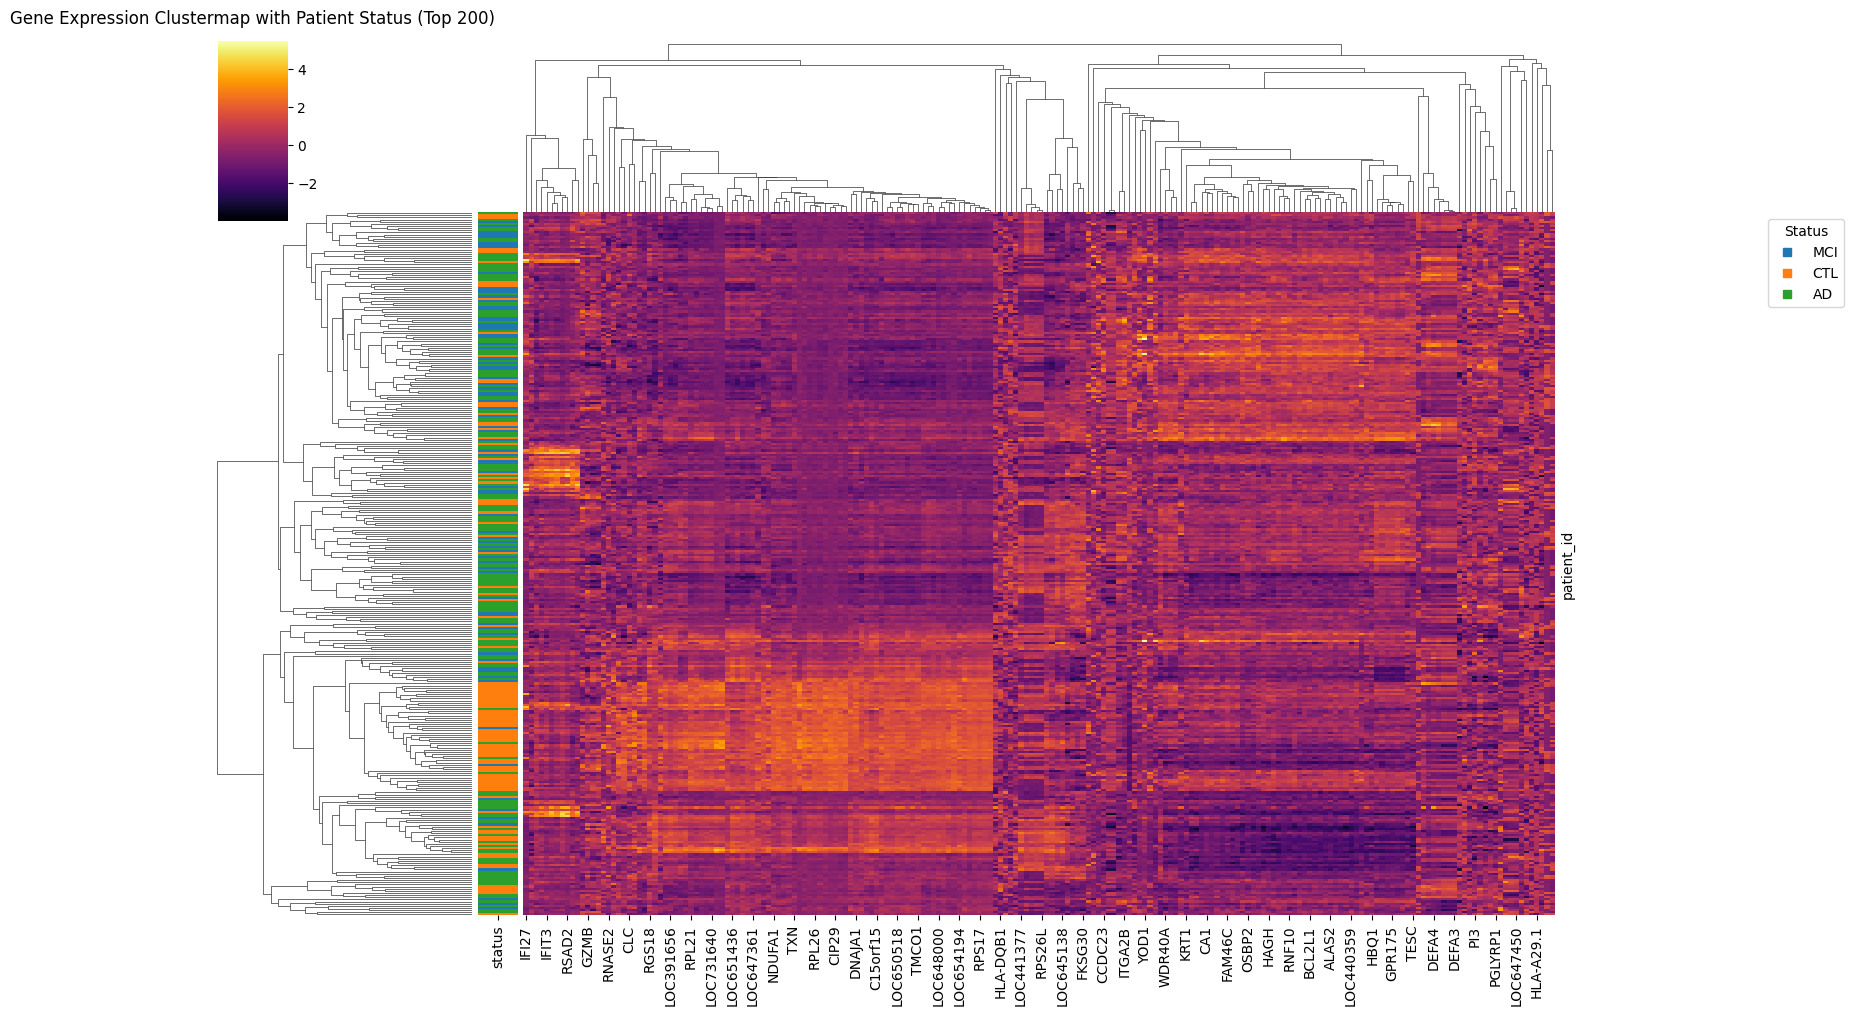

In [10]:
unique_statuses = status_labels.unique()

status_colors = dict(
    zip(unique_statuses, sns.color_palette("tab10", len(unique_statuses)))
)

row_colors = status_labels.map(status_colors)


g = sns.clustermap(
    gene_expression_df,
    row_colors=row_colors,
    cmap="inferno",
    figsize=(14, 10),
    metric="correlation",
    method="average",
    yticklabels=False
)


handles = [
    plt.Line2D([0], [0], marker='s', color=color, linestyle='', label=label)
    for label, color in status_colors.items()
]

g.ax_heatmap.legend(
    handles=handles,
    title="Status",
    bbox_to_anchor=(1.2, 1),
    loc="upper left"
)

plt.title("Gene Expression Clustermap with Patient Status (Top 200)", y=1.05)
plt.show()

In [11]:
import numpy as np
import pandas as pd
from scipy.stats import ttest_ind
from statsmodels.stats.multitest import multipletests

# -------------------------------
# Split groups
# -------------------------------
ad_df = GSE63060[GSE63060["status"] == "AD"].drop(columns=["status"])
ctrl_df = GSE63060[GSE63060["status"] == "CTL"].drop(columns=["status"])

results = []

# -------------------------------
# Gene-wise statistics
# -------------------------------
for gene in ad_df.columns:

    ad = ad_df[gene].dropna()
    ctrl = ctrl_df[gene].dropna()

    # mean expression
    ad_mean = ad.mean()
    ctrl_mean = ctrl.mean()

    # log2 fold change (correct form)
    log2fc = np.log2((ad_mean + 1e-9) / (ctrl_mean + 1e-9))

    # Welch t-test (better than equal variance t-test)
    stat, p = ttest_ind(ad, ctrl, equal_var=False, nan_policy="omit")

    results.append([gene, log2fc, p])

volcano_df = pd.DataFrame(results, columns=["Gene", "log2FC", "p_value"])

# -------------------------------
# FDR correction (CRITICAL for publication)
# -------------------------------
volcano_df["adj_p"] = multipletests(volcano_df["p_value"], method="fdr_bh")[1]

# -log10 transform
volcano_df["neg_log10_adj_p"] = -np.log10(volcano_df["adj_p"])

In [12]:
log2fc_thr = 0.00
p_thr = 0.05

volcano_df["category"] = "Not significant"

volcano_df.loc[
    (volcano_df["log2FC"] > log2fc_thr) & (volcano_df["adj_p"] < p_thr),
    "category"
] = "Upregulated"

volcano_df.loc[
    (volcano_df["log2FC"] < -log2fc_thr) & (volcano_df["adj_p"] < p_thr),
    "category"
] = "Downregulated"

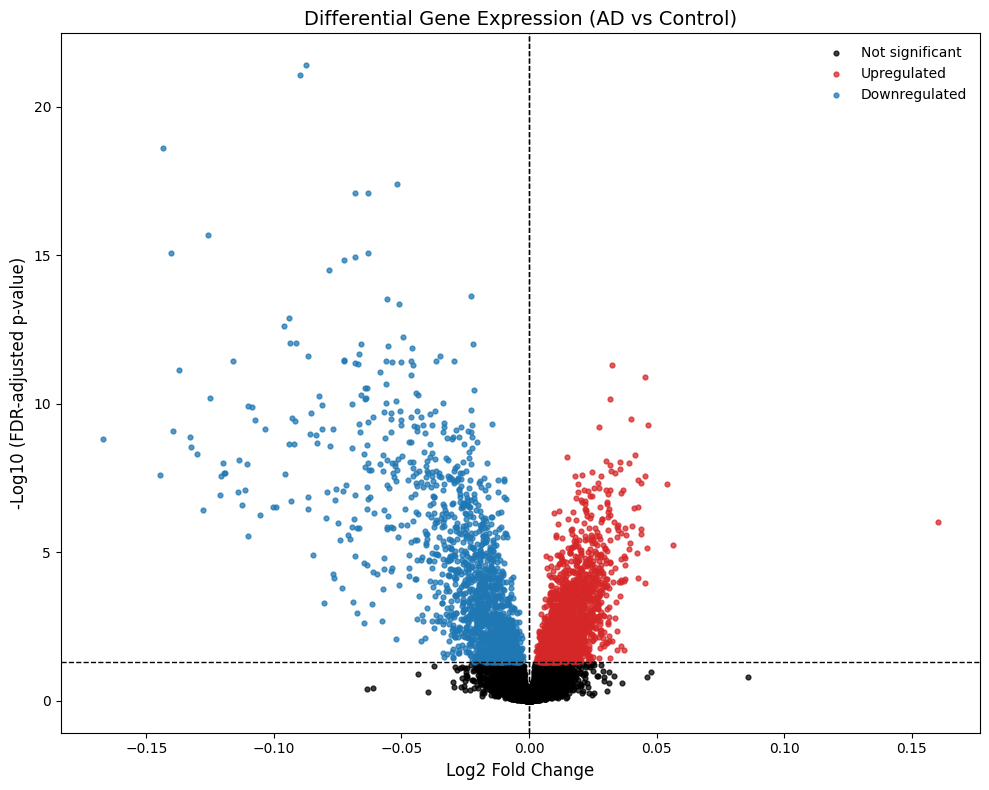

In [13]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 8))

colors = {
    "Not significant": "black",
    "Upregulated": "#d62728",   # deep red (Nature style)
    "Downregulated": "#1f77b4"  # deep blue
}

for cat, color in colors.items():
    subset = volcano_df[volcano_df["category"] == cat]

    plt.scatter(
        subset["log2FC"],
        subset["neg_log10_adj_p"],
        c=color,
        s=12,
        alpha=0.75,
        label=cat
    )

# -------------------------------
# Threshold lines (clean style)
# -------------------------------
plt.axvline(log2fc_thr, linestyle="--", color="black", linewidth=1)
plt.axvline(-log2fc_thr, linestyle="--", color="black", linewidth=1)
plt.axhline(-np.log10(p_thr), linestyle="--", color="black", linewidth=1)

plt.xlabel("Log2 Fold Change", fontsize=12)
plt.ylabel("-Log10 (FDR-adjusted p-value)", fontsize=12)
plt.title("Differential Gene Expression (AD vs Control)", fontsize=14)

plt.legend(frameon=False)
plt.tight_layout()

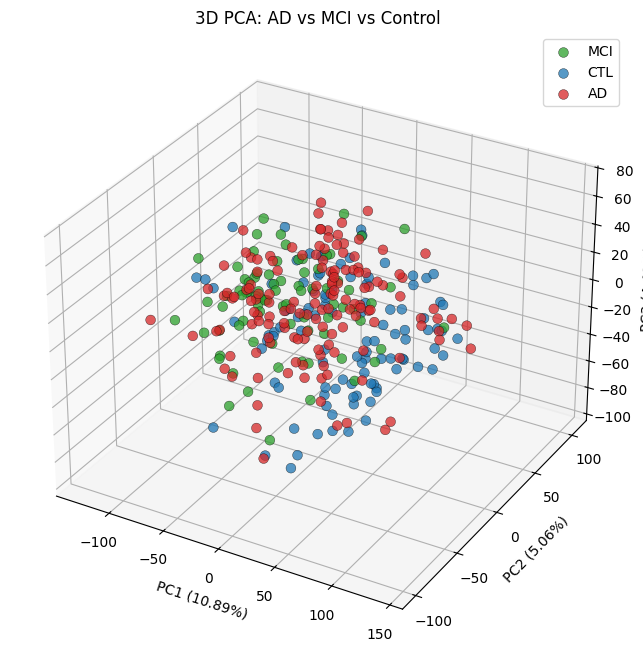

In [14]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
from mpl_toolkits.mplot3d import Axes3D

# -----------------------------
# Data
# -----------------------------
X = GSE63060.drop(columns=["status"])
y = GSE63060["status"]

# -----------------------------
# Standardize
# -----------------------------
X_scaled = StandardScaler().fit_transform(X)

# -----------------------------
# PCA (3 components)
# -----------------------------
pca = PCA(n_components=3)
components = pca.fit_transform(X_scaled)

pca_df = pd.DataFrame(components, columns=["PC1", "PC2", "PC3"])
pca_df["status"] = y.values

# -----------------------------
# 3D Plot
# -----------------------------
fig = plt.figure(figsize=(10, 8))
ax = fig.add_subplot(111, projection='3d')

colors = {
    "AD": "#d62728",
    "CTL": "#1f77b4",
    "MCI": "#2ca02c"
}

for group in pca_df["status"].unique():
    subset = pca_df[pca_df["status"] == group]

    ax.scatter(
        subset["PC1"],
        subset["PC2"],
        subset["PC3"],
        label=group,
        color=colors.get(group, "gray"),
        s=50,
        alpha=0.75,
        edgecolors="k",
        linewidths=0.3
    )

ax.set_xlabel(f"PC1 ({pca.explained_variance_ratio_[0]*100:.2f}%)")
ax.set_ylabel(f"PC2 ({pca.explained_variance_ratio_[1]*100:.2f}%)")
ax.set_zlabel(f"PC3 ({pca.explained_variance_ratio_[2]*100:.2f}%)")

ax.set_title("3D PCA: AD vs MCI vs Control")
ax.legend()

plt.show()

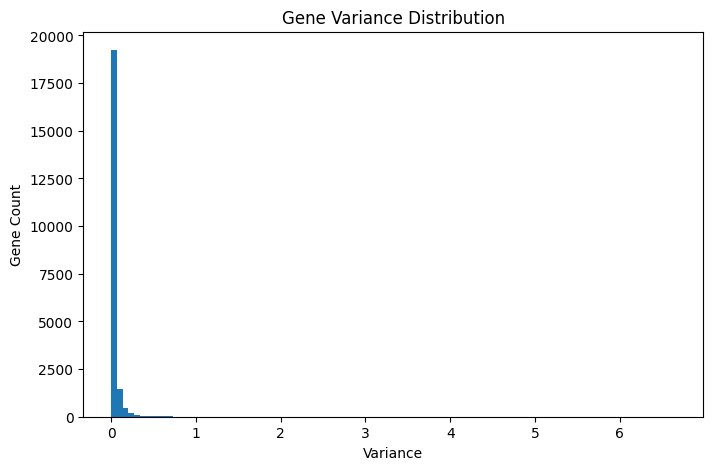

In [16]:
gene_variance = GSE63060.drop(columns=["status"]).var()

plt.figure(figsize=(8,5))
plt.hist(gene_variance, bins=100)
plt.title("Gene Variance Distribution")
plt.xlabel("Variance")
plt.ylabel("Gene Count")
plt.show()